# Pengenalan Pola Assignment#1: 1D Signal Classification<br>

Anggota Kelompok:<br>
Kenji Ratanaputra (24/534421/PA/22664) <br>
Thufail Bahir Al Bariq (24/537843/PA/22801) <br>
Marco Christian (24/539714/PA/22915) <br>

In [1]:
import os
import pandas as pd
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Dataset Overview

In [2]:
train = pd.read_csv(
    './cv-corpus-26.0-2026-06-12/id/train.tsv',
    sep='\t'
    )

In [3]:
test = pd.read_csv(
    './cv-corpus-26.0-2026-06-12/id/test.tsv',
    sep='\t'
    )

In [4]:
train

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,f1d28380afd1c969da598f80e2d17a498dc64046e23877...,common_voice_id_25903852.mp3,00e8b91090a086b2afaa2c40fd849b8255ff68528b6d63...,Penampilan kampus utama dikelola oleh program ...,NaN,2,0,twenties,female_feminine,NaN,NaN,id,NaN
1,f1d28380afd1c969da598f80e2d17a498dc64046e23877...,common_voice_id_25970221.mp3,013067a66ea456f15e2df06c53b7c930d64f3afd91e990...,Daerah padang pasir di barat daya dekat Tindou...,NaN,2,0,twenties,female_feminine,NaN,NaN,id,NaN
2,f1d28380afd1c969da598f80e2d17a498dc64046e23877...,common_voice_id_25970690.mp3,01b19ef0741ff210aecaf0b473738b147574ecfa98d331...,Normal untuk menganggapnya sebagai velositas d...,NaN,2,0,twenties,female_feminine,NaN,NaN,id,NaN
3,f1d28380afd1c969da598f80e2d17a498dc64046e23877...,common_voice_id_25970689.mp3,02056a9586b5e1a3af3dbb9ecbe927e23ce1998cd5337b...,Ada fazenda besar dan peternakan.,NaN,2,0,twenties,female_feminine,NaN,NaN,id,NaN
4,f1d28380afd1c969da598f80e2d17a498dc64046e23877...,common_voice_id_25970469.mp3,01ebf71d089009198414d4f8c9187abf48fb240a383c9d...,"Dalam beberapa kasus, bukti geokimia dapat dit...",NaN,2,0,twenties,female_feminine,NaN,NaN,id,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,6ac0427a8caef565e3a800e844451a5dde7df70a144fae...,common_voice_id_26269851.mp3,009292d5c78aa170e713a4be7e5417bba657c11fc23868...,"Saudara lelakinya, David, adalah seorang musisi.",NaN,2,0,NaN,NaN,NaN,NaN,id,NaN
4977,6ac0427a8caef565e3a800e844451a5dde7df70a144fae...,common_voice_id_26269852.mp3,00a3659b374733972c60daf9ca65d5bd9bd45e1c080b01...,Klub tahunan itu juga bertanding di Euroleague.,NaN,2,1,NaN,NaN,NaN,NaN,id,NaN
4978,6ac0427a8caef565e3a800e844451a5dde7df70a144fae...,common_voice_id_26269854.mp3,00854d60ba809d51c4d6dbecc2e347035c99ee6a28891f...,Sebelumnya memiliki otorisasi untuk memberikan...,NaN,2,0,NaN,NaN,NaN,NaN,id,NaN
4979,6ac0427a8caef565e3a800e844451a5dde7df70a144fae...,common_voice_id_26269862.mp3,0018fd0d74d317114f74cf6a9ada967ed6b256f5d9f3d2...,"Namun, selama Musim Semi, biasanya pada bulan ...",NaN,2,0,NaN,NaN,NaN,NaN,id,NaN


In [5]:
test

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,fab876600ae7fdf0bb5a625115a11c162ec98931e03563...,common_voice_id_23817543.mp3,055624c6d39df7950b312bb56617df9c9e6d9863c641c7...,saya tidak suka tidur siang,NaN,2,0,twenties,male_masculine,NaN,NaN,id,NaN
1,fab876600ae7fdf0bb5a625115a11c162ec98931e03563...,common_voice_id_23769335.mp3,c8bb060a490bfb3e1b22cfb0de41e2a6f17da227a98f34...,Kita bisa mencari jati diri kita sendiri.,NaN,2,0,twenties,male_masculine,NaN,NaN,id,NaN
2,fab876600ae7fdf0bb5a625115a11c162ec98931e03563...,common_voice_id_23817591.mp3,077d6df8d565a2dbd1ac6c8b37ce137580e6169856eff6...,Aku pun merasa akan enak jika pergi ke arah ba...,NaN,2,0,twenties,male_masculine,NaN,NaN,id,NaN
3,fab876600ae7fdf0bb5a625115a11c162ec98931e03563...,common_voice_id_23769283.mp3,f53e2bde6d90978e2f3ad8b565974f890afb78703b45f6...,Tak jarang dia pulang membawa oleh-oleh.,NaN,2,0,twenties,male_masculine,NaN,NaN,id,NaN
4,bc6cdb2d920809ca8a893ebb4a12cdffbd5e99f984a7c1...,common_voice_id_20362404.mp3,be007164980b542850e90eb80fe752f2d45e4cb838c124...,Saya memasukkan kartu ke dompet.,NaN,3,0,fourties,male_masculine,NaN,NaN,id,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,0a64c046530244b7507d4404575e8f673613c939ad6fac...,common_voice_id_40088845.mp3,67125efffe8d90c1147d6d609ca9e041f17b1a78b6a3d2...,"Pada akhirnya, dia memilih anak kucing yang sa...",NaN,2,0,NaN,NaN,NaN,NaN,id,NaN
3696,0a4e7e60acc2a6145fc2589e6abb81e41e430cea0611bd...,common_voice_id_23033570.mp3,ecee266f978e8296fc17d2bcfa744429165db882dbe5fd...,Maha Suci Allah.,NaN,2,0,teens,male_masculine,NaN,NaN,id,NaN
3697,025f07759891360d312521dd83679fa6a233b9d7aa9d4a...,common_voice_id_27657418.mp3,34f56b62e91fbbffeb7df499d4486aaa9f6d963a93d57f...,Berharap kau di sini.,NaN,2,0,teens,male_masculine,NaN,NaN,id,NaN
3698,018b3f1a0a941a5b881a886830d9f133402ed66409489a...,common_voice_id_32165882.mp3,dd457d82f974202742803bf426f129d339fb1cf2217876...,Aku juga tidak mengerti.,NaN,2,0,NaN,NaN,NaN,NaN,id,NaN


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        4981 non-null   object 
 1   path             4981 non-null   object 
 2   sentence_id      4981 non-null   object 
 3   sentence         4981 non-null   object 
 4   sentence_domain  0 non-null      float64
 5   up_votes         4981 non-null   int64  
 6   down_votes       4981 non-null   int64  
 7   age              2985 non-null   object 
 8   gender           2985 non-null   object 
 9   accents          0 non-null      float64
 10  variant          0 non-null      float64
 11  locale           4981 non-null   object 
 12  segment          0 non-null      float64
dtypes: float64(4), int64(2), object(7)
memory usage: 506.0+ KB


In [7]:
train['gender'].value_counts()

gender
male_masculine     1728
female_feminine    1257
Name: count, dtype: int64

In [8]:
train['gender'].isnull().sum()

np.int64(1996)

In [9]:
test['gender'].value_counts()

gender
male_masculine     1684
female_feminine     457
Name: count, dtype: int64

In [10]:
test['gender'].isnull().sum()

np.int64(1559)

In [40]:
print("Unique speaker per gender (train):")
print(train.dropna(subset=['gender']).groupby('gender')['client_id'].nunique())
print()
print("Number of clips per speaker (train, top 10):")
print(train.dropna(subset=['gender'])['client_id'].value_counts().head(10))
print()
print("Unique speaker per gender (test):")
print(test.dropna(subset=['gender']).groupby('gender')['client_id'].nunique())


Unique speaker per gender (train):
gender
female_feminine    1
male_masculine     1
Name: client_id, dtype: int64

Number of clips per speaker (train, top 10):
client_id
5b9d421df111585add2c3f9649306e4deaf9cb56cd1e229705c5eb2d861e045af732015134d44937a9777efb0e742f770b943dd195e1b597de98f6f1ed8b72cd    1728
f1d28380afd1c969da598f80e2d17a498dc64046e2387736e4e91940ffdedab63ac1ffb8b63da9597876dd0e8c476e6116ae468978e827c2b2bbea12301e5fa4    1257
Name: count, dtype: int64

Unique speaker per gender (test):
gender
female_feminine     33
male_masculine     143
Name: client_id, dtype: int64


### Preprocessing

Take only path and gender for the classification

In [12]:
df_train = train[['path', 'gender']]
df_test = test[['path', 'gender']]

Drop null values

In [13]:
before = len(df_train)
df_train = df_train.dropna()
after = len(df_train)

print(f"Rows dropped: {before - after}")

Rows dropped: 1996


In [14]:
before = len(df_test)
df_test  = df_test.dropna()
after = len(df_test)

print(f"Rows dropped: {before - after}")

Rows dropped: 1559


Create column for complete audio file path

In [15]:
CLIPS_PATH = "./cv-corpus-26.0-2026-06-12/id/clips"

df_train['audio_path'] = df_train['path'].apply(
    lambda x: f"{CLIPS_PATH}/{x}"
)

df_test['audio_path'] = df_test['path'].apply(
    lambda x: f"{CLIPS_PATH}/{x}"
)

Check if file actually exists in folder

In [16]:
df_train['valid_file'] = df_train['audio_path'].apply(
    lambda x: os.path.exists(x)
)

df_test['valid_file'] = df_test['audio_path'].apply(
    lambda x: os.path.exists(x)
)

In [17]:
print("Train files not found:", (~df_train['valid_file']).sum())
print("Test files not found:", (~df_test['valid_file']).sum())

Train files not found: 0
Test files not found: 0


In [18]:
df_train = df_train.drop(columns=['valid_file'])
df_test = df_test.drop(columns=['valid_file'])

Labels the target value (gender) to numeric value

In [19]:
label_mapping = {
    "male_masculine": 0,
    "female_feminine": 1
}

df_train['label'] = df_train['gender'].map(label_mapping)
df_test['label'] = df_test['gender'].map(label_mapping)

In [20]:
pd.set_option("display.max_colwidth", None)
df_train

,path,gender,audio_path,label
0,common_voice_id_25903852.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_25903852.mp3,1
1,common_voice_id_25970221.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_25970221.mp3,1
2,common_voice_id_25970690.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_25970690.mp3,1
3,common_voice_id_25970689.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_25970689.mp3,1
4,common_voice_id_25970469.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_25970469.mp3,1
...,...,...,...,...
3722,common_voice_id_26228452.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_26228452.mp3,0
3723,common_voice_id_26228451.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_26228451.mp3,0
3724,common_voice_id_26228444.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_26228444.mp3,0
3725,common_voice_id_26228443.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_26228443.mp3,0


In [21]:
df_test

,path,gender,audio_path,label
0,common_voice_id_23817543.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23817543.mp3,0
1,common_voice_id_23769335.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23769335.mp3,0
2,common_voice_id_23817591.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23817591.mp3,0
3,common_voice_id_23769283.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23769283.mp3,0
4,common_voice_id_20362404.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_20362404.mp3,0
...,...,...,...,...
3679,common_voice_id_23933132.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23933132.mp3,0
3682,common_voice_id_27389019.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_27389019.mp3,1
3689,common_voice_id_39610466.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_39610466.mp3,0
3696,common_voice_id_23033570.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23033570.mp3,0


Test to load an audio file

In [22]:
audio_path = df_train.iloc[0]["audio_path"]

audio, sr = librosa.load(
    audio_path,
    sr=16000,
    mono = True
)

In [23]:
print("Sampling rate    :", sr)
print("Number of sample :", len(audio))
print("Duration         :", len(audio) / sr, "detik")

Sampling rate    : 16000
Number of sample : 109440
Duration         : 6.84 detik


<function matplotlib.pyplot.show(close=None, block=None)>

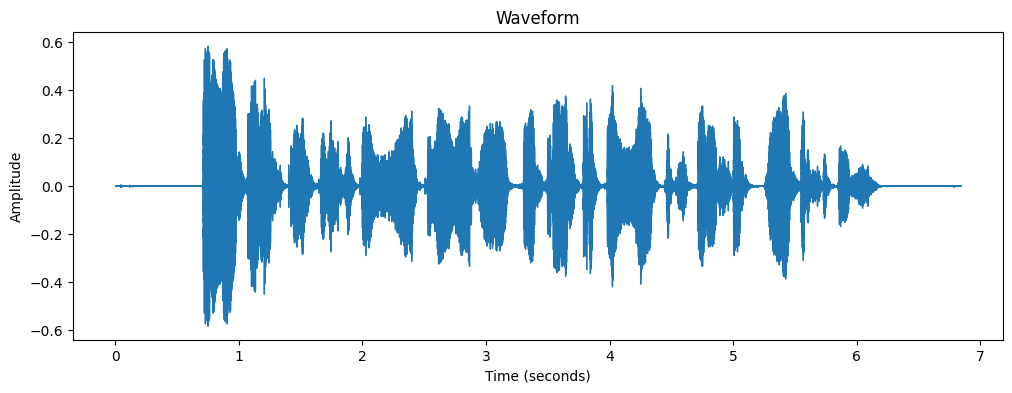

In [24]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show


### Feature Extraction

Extract audio features using **MFCC, Zero-Crossing Rate (ZCR), Spectral Centroid, Spectral Bandwidth, RMS Energy, and Fundamental Frequency (F0/pitch)**. For each feature, the mean and standard deviation are calculated to obtain a fixed-length representation. All resulting features are concatenated into a single feature vector. In total, each audio sample is represented by **36 features**.

In [ ]:
def extract_features(audio_path):
    try:
        #Load audio
        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        #Normalize
        audio = librosa.util.normalize(audio)

        #MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        #ZCR
        zcr = librosa.feature.zero_crossing_rate(audio)

        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)

        #Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )

        spectral_centroid_mean = np.mean(spectral_centroid)
        spectral_centroid_std = np.std(spectral_centroid)

        #Spectral Bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(
            y=audio,
            sr=sr
        )

        spectral_bandwidth_mean = np.mean(spectral_bandwidth)
        spectral_bandwidth_std = np.std(spectral_bandwidth)

        #RMS
        rms = librosa.feature.rms(y=audio)

        rms_mean = np.mean(rms)
        rms_std = np.std(rms)

        #F0/Pitch
        f0, voiced_flag, voiced_prob = librosa.pyin(
            audio,
            fmin=50,
            fmax=400,
            sr=sr
        )

        if np.any(~np.isnan(f0)):
            f0_mean = np.nanmean(f0)
            f0_std = np.nanstd(f0)
        else:
            f0_mean = 0.0
            f0_std = 0.0

        #Combine all features
        features = np.concatenate([
            mfcc_mean,
            mfcc_std,
            [zcr_mean, zcr_std],
            [spectral_centroid_mean, spectral_centroid_std],
            [spectral_bandwidth_mean, spectral_bandwidth_std],
            [rms_mean, rms_std],
            [f0_mean, f0_std]
        ])

        return features

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None


Test to extract features from an audio file

In [26]:
features = extract_features(audio_path)
print(features)
print("Number of features:", len(features))

[-2.51582962e+02  6.31693497e+01 -4.20902205e+00  3.62408867e+01
 -2.39739132e+01 -2.95875645e+00 -9.23521423e+00 -2.02100220e+01
 -9.46892738e+00 -9.03471851e+00 -1.26912498e+01 -9.66236115e+00
 -5.47173023e+00  1.29194016e+02  6.52742996e+01  4.25839424e+01
  3.45821419e+01  2.27583160e+01  1.79670506e+01  1.62542992e+01
  2.03883057e+01  1.59078684e+01  1.16321154e+01  1.21480188e+01
  1.20209150e+01  1.00338278e+01  1.51490399e-01  1.41426962e-01
  1.86258789e+03  1.09727329e+03  1.53273463e+03  4.15515893e+02
  1.19983837e-01  1.03134707e-01  2.40640624e+02  3.36105978e+01]
Number of features: 36


Apply feature extraction to all audio file

In [27]:
#Sample data for pipeline testing
#df_train_sample = df_train.head(500).copy()
#df_test_sample = df_test.head(200).copy()

In [28]:
X_train_list = []
y_train_list = []

for _, row in df_train.iterrows():
    features = extract_features(row['audio_path'])

    if features is not None:
        X_train_list.append(features)
        y_train_list.append(row['label'])

In [29]:
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

print(X_train.shape)
print(y_train.shape)

(2985, 36)
(2985,)


In [30]:
X_test_list = []
y_test_list = []

for _, row in df_test.iterrows():
    features = extract_features(row['audio_path'])

    if features is not None:
        X_test_list.append(features)
        y_test_list.append(row['label'])

In [31]:
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print(X_test.shape)
print(y_test.shape)

(2141, 36)
(2141,)


### Modeling and Classification

Apply standardization scaling on features

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SVM

In [33]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=41)

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=41),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params        :", grid_search.best_params_)
print("Best CV bal. acc.   :", grid_search.best_score_)

svm = grid_search.best_estimator_


Best params        : {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV bal. acc.   : 1.0


In [34]:
y_pred = svm.predict(X_test_scaled)

In [35]:
print(classification_report(y_test, y_pred, target_names=["Male", "Female"]))

              precision    recall  f1-score   support

        Male       0.90      0.44      0.59      1684
      Female       0.28      0.82      0.42       457

    accuracy                           0.52      2141
   macro avg       0.59      0.63      0.51      2141
weighted avg       0.77      0.52      0.56      2141



In [36]:
from sklearn.metrics import balanced_accuracy_score

y_train_pred = svm.predict(X_train_scaled)

print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred, target_names=["Male", "Female"]))
print("Balanced accuracy (train):", balanced_accuracy_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("Balanced accuracy (test) :", balanced_accuracy_score(y_test, y_pred))


=== TRAIN ===
              precision    recall  f1-score   support

        Male       1.00      1.00      1.00      1728
      Female       1.00      1.00      1.00      1257

    accuracy                           1.00      2985
   macro avg       1.00      1.00      1.00      2985
weighted avg       1.00      1.00      1.00      2985

Balanced accuracy (train): 1.0

=== TEST ===
Balanced accuracy (test) : 0.6302963403795278


In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[741 943]
 [ 82 375]]


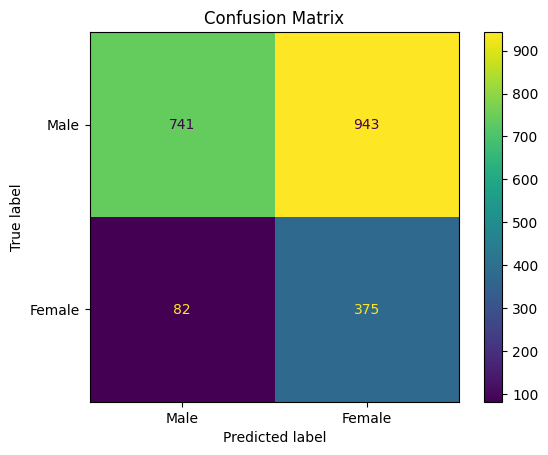

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Male", "Female"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()